# Visualize CutMix Augmentation
This notebook demonstrates the output of the CutMix augmentation on different images, drawing a colored boundary box around the CutMix patch for each image.

## 1. Create a New Git Branch
Use the integrated terminal in Visual Studio Code to create a new branch named 'testing' with:

```
git checkout -b testing
```

In [2]:
# Visualize CutMix on test set images using your project logic
import sys
import os
SCRIPT_DIR = os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(SCRIPT_DIR, '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import torch
from torch.utils.data import DataLoader
from src.data.coco_dataset import COCODataset, ImageSegmentationDataset
from src.utils.palette import label2id, palette, id2color
import matplotlib.pyplot as plt
import numpy as np
from PIL import ImageDraw, Image
import matplotlib.colors as mcolors
import yaml
import torchvision.transforms.functional as TF
# cutmix class import
from src.data.cutmix import SegmentationCutMix
from src.data.cutmix import get_cutmix_transform

In [3]:
# 2. Define a new "_cutmix" function that is identical to the original,
#    but adds a return statement for the bounding box coordinates.
def _modified_cutmix(self, imgs, masks):
    # This is the exact core logic from your cutmix.py file
    B, _, H, W = imgs.shape
    lam = np.random.beta(self.alpha, self.alpha) if self.alpha > 0 else 1.
    rw, rh = int(W * np.sqrt(1 - lam)), int(H * np.sqrt(1 - lam))
    cx, cy = np.random.randint(W), np.random.randint(H)
    x1, y1 = np.clip(cx - rw // 2, 0, W), np.clip(cy - rh // 2, 0, H)
    x2, y2 = np.clip(cx + rw // 2, 0, W), np.clip(cy + rh // 2, 0, H)

    mix_imgs  = imgs.clone()
    for i in range(B):
        j = (i + 1) % B
        mix_imgs[i,:, y1:y2, x1:x2] = imgs[j,:, y1:y2, x1:x2]

    mix_masks = masks.clone()
    for i in range(B):
        j = (i + 1) % B
        mix_masks[i, y1:y2, x1:x2] = masks[j, y1:y2, x1:x2]

    # The only change is here: we return the calculated box
    return mix_imgs, mix_masks, (x1, y1, x2, y2)

# 3. Define a new "__call__" function that handles the new return value.
def __modified_call(self, imgs, masks):
    if np.random.rand() > self.prob:
        # If no cutmix, return the original images and None for the box
        return imgs, masks, None
    # Otherwise, call our new _modified_cutmix function
    return self._cutmix(imgs, masks)

# 4. Replace the original methods on the class with our modified versions
SegmentationCutMix._cutmix = _modified_cutmix
SegmentationCutMix.__call__ = __modified_call

print("✅ SegmentationCutMix has been successfully patched in memory.")
print("   You can now use it to get bounding box coordinates without editing cutmix.py.")

✅ SegmentationCutMix has been successfully patched in memory.
   You can now use it to get bounding box coordinates without editing cutmix.py.


In [4]:
# --- Denormalization Function (for visualization) ---
# Using the same stats as in your notebook
ADE_MEAN = np.array([123.675, 116.280, 103.530]) / 255.0
ADE_STD = np.array([58.395, 57.120, 57.375]) / 255.0

def denormalize(tensor):
    """
    Safely denormalizes a tensor for visualization. It intelligently checks
    the tensor's value range to decide on the correct strategy.
    """
    tensor = tensor.clone().cpu().detach()

    # NEW: If the max value is > 1.0, it's in the [0, 255] range.
    # We must scale it down to [0.0, 1.0] first.
    if tensor.max() > 1.0:
        tensor.div_(255.0)

    # If the image has negative values, it's normalized. Reverse it.
    elif tensor.min() < 0:
        mean = torch.tensor(ADE_MEAN, dtype=tensor.dtype).view(3, 1, 1)
        std = torch.tensor(ADE_STD, dtype=tensor.dtype).view(3, 1, 1)
        tensor.mul_(std).add_(mean)

    # Clamp the values to the valid [0, 1] range for display
    tensor.clamp_(0, 1)

    return TF.to_pil_image(tensor)

# --- Visualization Function ---
def visualize_cutmix(dataloader, alpha, prob, num_classes, num_images=4):
    """Applies CutMix and plots the original vs. augmented images."""
    cutmix_transform = SegmentationCutMix(num_classes=num_classes, alpha=alpha, prob=prob)

    # Get a single batch of data from your dataloader
    # We use underscores (_) to ignore the last two values we don't need.
    images, masks, _, _ = next(iter(dataloader))
       # --- Optional Debugging ---
    # Uncomment these lines if you still have issues
    print(f"Image batch shape: {images.shape}, dtype: {images.dtype}")
    print(f"Image value range: min={images.min():.2f}, max={images.max():.2f}")
     
    # Apply the (now patched) CutMix transformation
    mixed_images, _, box = cutmix_transform(images, masks)

    # Plot the results
    fig, axes = plt.subplots(num_images, 2, figsize=(10, num_images * 5))
    fig.suptitle(f'CutMix Visualization (alpha={alpha}, prob={prob})', fontsize=16, y=1.02)

    for i in range(min(num_images, len(images))):
        # Column 1: Original Image
        original_img_pil = denormalize(images[i])
        axes[i, 0].imshow(original_img_pil)
        axes[i, 0].set_title(f'Original Image {i}')
        axes[i, 0].axis('off')

        # Column 2: CutMix Image with Bounding Box
        mixed_img_pil = denormalize(mixed_images[i])
        axes[i, 1].imshow(mixed_img_pil)
        axes[i, 1].set_title(f'CutMix Result {i}')
        axes[i, 1].axis('off')

        # Draw the red bounding box if CutMix was applied
        if box is not None:
            x1, y1, x2, y2 = box
            draw = ImageDraw.Draw(mixed_img_pil)
            draw.rectangle([x1, y1, x2, y2], outline="red", width=6)
            axes[i, 1].imshow(mixed_img_pil)

    plt.tight_layout()
    plt.show()


In [5]:
def get_matplotlib_cmap():
    """
    Creates a matplotlib ListedColormap from the project's hex color palette.
    The background (class 0) is made fully transparent.
    """
    palette_rgb = []
    for i in range(len(id2color)):
        # Convert hex to RGB normalized to [0, 1]
        rgb = mcolors.to_rgb(id2color[i])
        palette_rgb.append(rgb)
    
    # Create the colormap
    cmap = mcolors.ListedColormap(palette_rgb)
    
    # Make the background class (index 0) transparent
    cmap_colors = cmap.colors
    cmap_colors[0] = (*cmap_colors[0], 0.0) # Add alpha channel, 0.0 = transparent
    return mcolors.ListedColormap(cmap_colors)

# --- Denormalization Function ---
def denormalize(tensor):
    """Safely denormalizes an image tensor for visualization."""
    tensor = tensor.clone().cpu().detach()
    if tensor.max() > 1.0:
        tensor.div_(255.0)
    tensor.clamp_(0, 1)
    return TF.to_pil_image(tensor)

# --- Visualization Function ---
def visualize_cutmix(dataloader, alpha, prob, num_classes, num_images=4):
    """Applies CutMix and plots images with segmentation mask overlays using matplotlib."""
    cmap = get_matplotlib_cmap()
    
    cutmix_transform = SegmentationCutMix(num_classes=num_classes, alpha=alpha, prob=prob)

    images, masks, _, _ = next(iter(dataloader))
    # images = images.contiguous() # Ensure memory is contiguous

    mixed_images, mixed_masks, box = cutmix_transform(images, masks)

    fig, axes = plt.subplots(num_images, 2, figsize=(12, num_images * 6))
    fig.suptitle(f'CutMix Visualization (alpha={alpha}, prob={prob})', fontsize=16, y=1.02)

    for i in range(min(num_images, len(images))):
        # --- Column 1: Original Image with Mask Overlay ---
        original_img_np = denormalize(images[i])
        original_mask_np = masks[i].cpu().numpy()
        
        axes[i, 0].imshow(original_img_np) # Draw the photo
        axes[i, 0].imshow(original_mask_np, cmap=cmap, alpha=0.6, vmin=0, vmax=num_classes-1) # Overlay the mask
        axes[i, 0].set_title(f'Original Image + Mask {i}')
        axes[i, 0].axis('off')

        # --- Column 2: CutMix Result with Mask Overlay and Bounding Box ---
        mixed_img_np = denormalize(mixed_images[i])
        mixed_mask_np = mixed_masks[i].cpu().numpy()

        axes[i, 1].imshow(mixed_img_np) # Draw the mixed photo
        axes[i, 1].imshow(mixed_mask_np, cmap=cmap, alpha=0.6, vmin=0, vmax=num_classes-1) # Overlay the mixed mask
        axes[i, 1].set_title(f'CutMix Result + Mask {i}')
        axes[i, 1].axis('off')

        if box is not None:
            x1, y1, x2, y2 = box
            # Create a rectangle patch and add it to the axes
            rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor='red', facecolor='none')
            axes[i, 1].add_patch(rect)

    plt.tight_layout()
    plt.show()


--- Visualizing for alpha=0.5, prob=1.0 ---


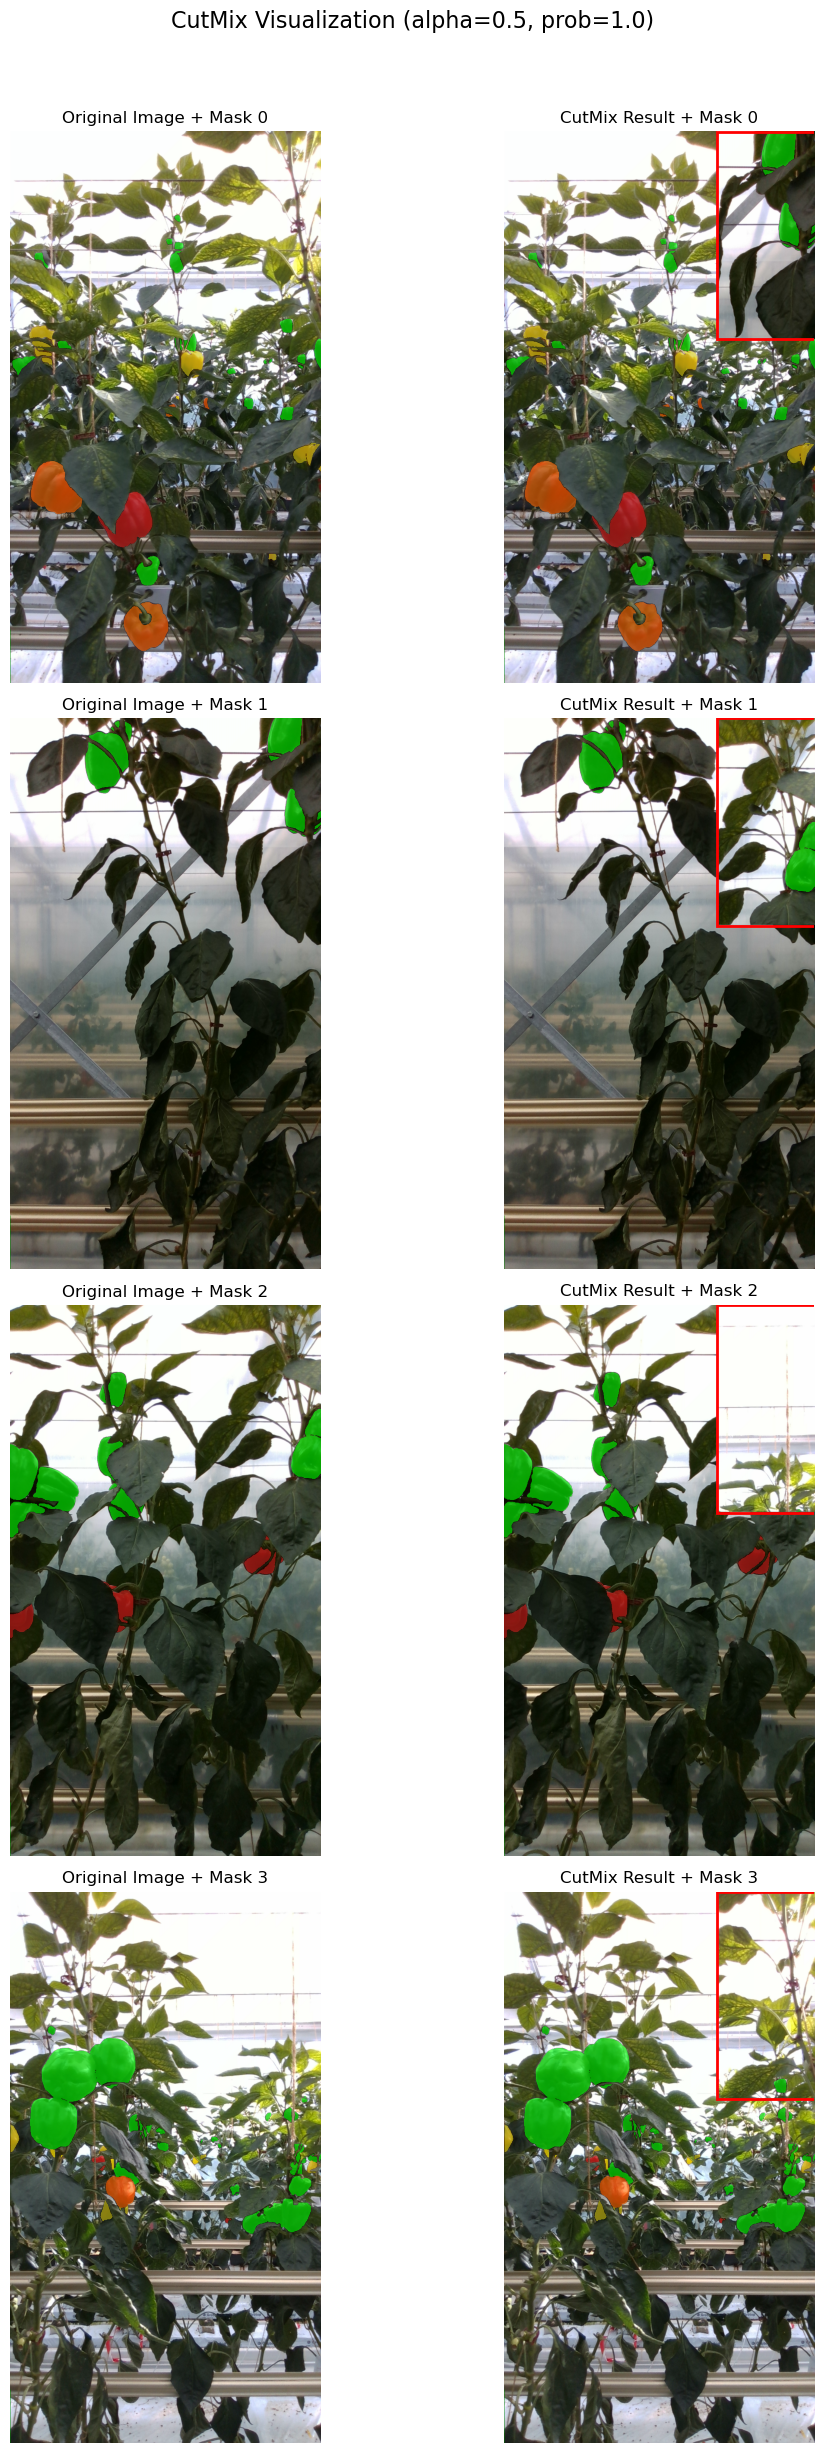

--- Visualizing for alpha=1.0, prob=1.0 ---


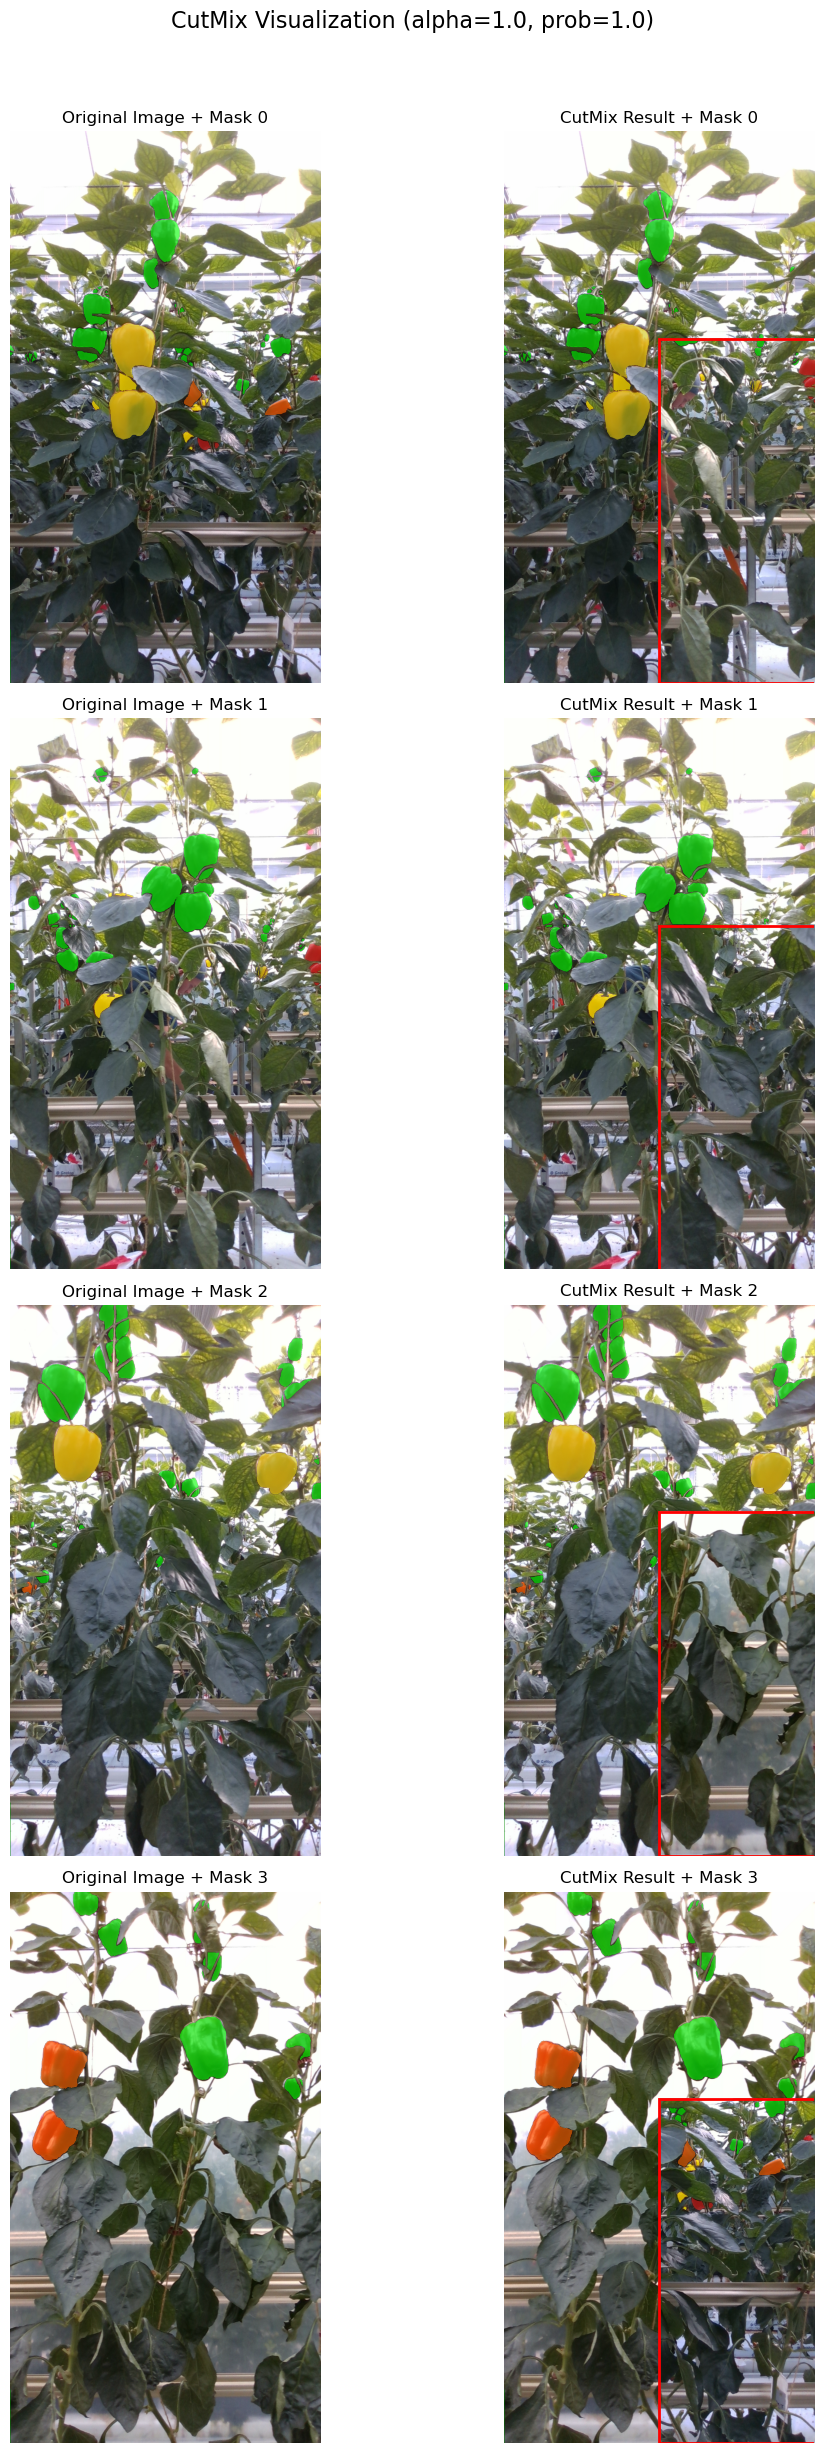

--- Visualizing for alpha=1.5, prob=1.0 ---


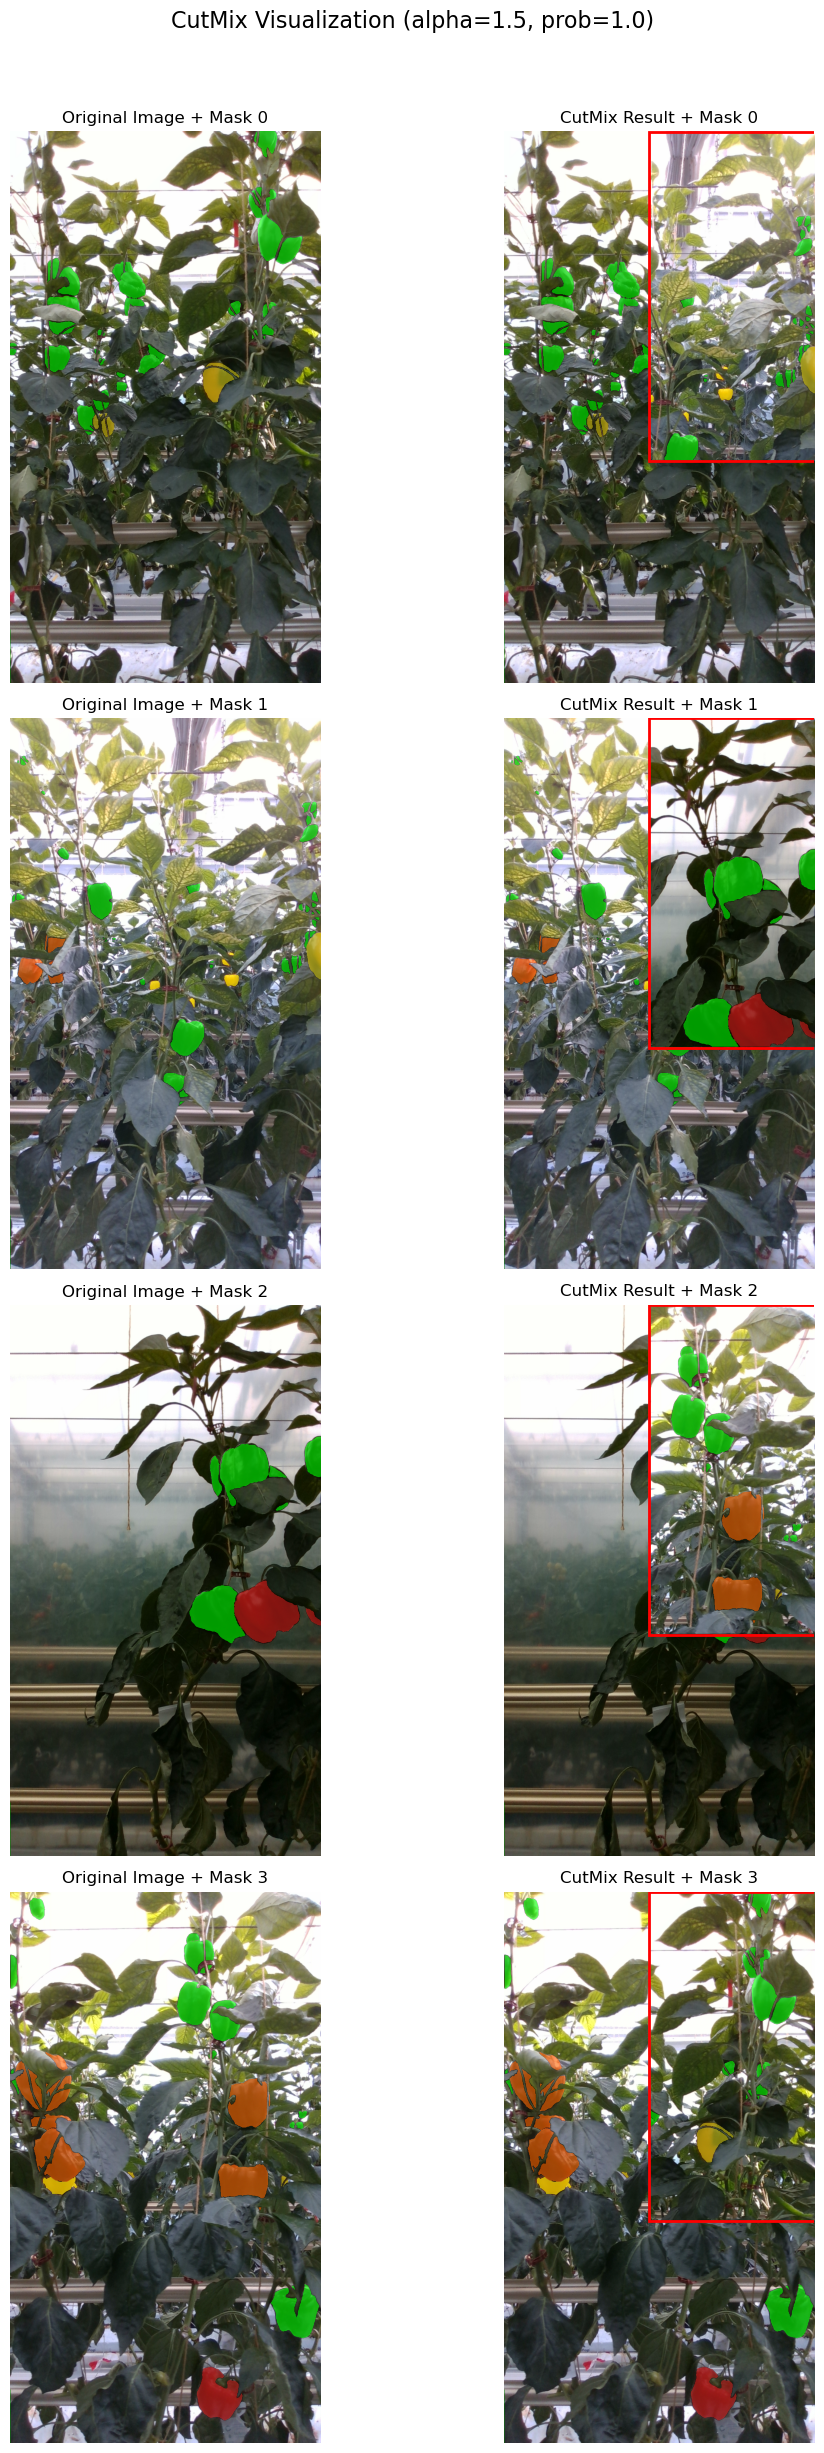

In [6]:
# --- Main Execution ---
if __name__ == '__main__':
    # Load hyperparameters from your grid_config.yaml
    with open('../grid_config.yaml', 'r') as f:
        config = yaml.safe_load(f)
    
    cutmix_alphas = config['parameters']['cutmix_alpha']['values']
    cutmix_probs = config['parameters']['cutmix_prob']['values']
    # --- Config ---
    coco_json = '/Users/rk/Downloads/Thesis/CKA_sweet_pepper_2020_summer/CKA_sweet_pepper_2020_summer.json'
    img_root = '/Users/rk/Downloads/Thesis/'
    batch_size = 4
    num_classes = len(label2id)

    # --- Load test set ---
    base_dataset = COCODataset(coco_json, img_root, split='test')
    dataset = ImageSegmentationDataset(base_dataset, label2id=label2id)
    test_dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # This check ensures the dataloader is defined before running
    if 'test_dataloader' not in locals():
        raise NameError("Please define your 'test_dataloader' in the section above.")

    # Visualize for each hyperparameter combination
    NUM_CLASSES = 8 # From your palette.py
    cutmix_probs = [1.0]  # Ensure prob=1.0 is included for visualization
    for alpha in cutmix_alphas:
        for prob in cutmix_probs:
            print(f"--- Visualizing for alpha={alpha}, prob={prob} ---")
            visualize_cutmix(test_dataloader, alpha=alpha, prob=prob, num_classes=NUM_CLASSES)